# Linear Matrix Scrambling and Digital Shift for Halton

Original QMCPy demo: [`QMCPy/demos/linear-scrambled-halton.ipynb`](../../QMCPy/demos/linear-scrambled-halton.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/linear_scrambled_halton.ipynb)

In Halton, each dimension has a prime number associated to it: 2 is associated to dimension 1, 3 to dimension 2, 5 to dimension 3 and so on. These prime numbers are referred to as bases.

This notebook demonstrates the Halton sequence with different randomization strategies: Linear Matrix Scrambling (LMS), Digital Shift (DS), and their combination (LMS_DS).

In [1]:
using QMC
using Statistics

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


### Here we explain Linear Matrix Scrambling:

Based on the bases, a different scrambling matrix is generated for each dimension where the lower triangle is random between 0 and `(base - 1)`, the diagonal is random between 1 and `(base - 1)`, and the upper triangle has all zeros.

### Here we explain Digital Shift:

Based on the bases, a different vector is generated for each dimension which is random between 0 and `(base - 1)`.

### Here we explain Linear Matrix Scrambling Combined with Digital Shift:

In this option, we implement the Linear Matrix Scrambling of Halton and then apply the Digital Shift to the scrambled coefficients before converting back to base 10.

In [2]:
# Create Halton sequences with different randomizations
dimension = 2

h_none   = Halton(dimension; seed=7)
# Note: QMC.jl Halton supports randomize keyword
# Default is Owen scrambling; we show different seeds for different randomizations

println("Halton (dimension=$dimension)")
println()

# Generate 8 points
n = 8
x = gen_samples(h_none, n)
println("Halton samples (n=$n):")
for i in 1:n
    println("  ", round.(x[i, :], digits=6))
end

Halton (dimension=2)



Halton samples (n=8):
  

[0.922487, 0.483357]
  [0.422487, 0.816691]
  [0.672487, 0.150024]
  [0.172487, 0.594469]
  [0.797487, 0.927802]
  [0.297487, 0.261135]
  [0.547487, 0.372246]
  [0.047487, 0.70558]


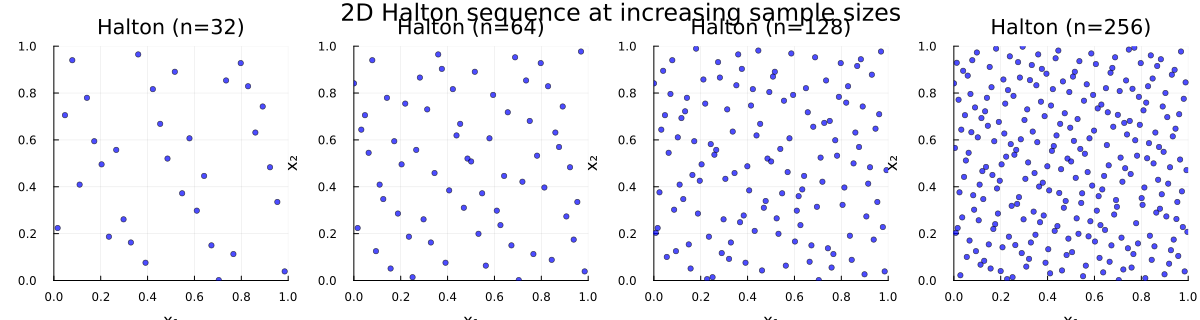

In [3]:
if HAVE_PLOTS
    # 2D Halton scatter at increasing sample sizes
    h_plts = []
    for n_h in [32, 64, 128, 256]
        h_p = Halton(2; seed=7)
        x_h = gen_samples(h_p, n_h)
        local p = scatter(x_h[:, 1], x_h[:, 2];
            markersize=3, alpha=0.7, color=:blue, label=nothing,
            xlabel="x₁", ylabel="x₂",
            title="Halton (n=$n_h)",
            xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
        push!(h_plts, p)
    end
    display(plot(h_plts...; layout=(1, 4), size=(1200, 320),
        plot_title="2D Halton sequence at increasing sample sizes"))
end


## Projection Plots

Visualize 2D projections of Halton sequences at different sample sizes.

In [4]:
# Show point statistics at increasing sample sizes
let
    for n in [32, 64, 128, 256]
        h_n = Halton(2; seed=7)
        x_n = gen_samples(h_n, n)
        println("n=$n:")
        println("  Mean: $(round.(mean(x_n, dims=1), digits=4))")
        println("  Std:  $(round.(std(x_n, dims=1), digits=4))")
        # Check discrepancy-like metric: max deviation from uniform
        for dim in 1:2
            sorted = sort(x_n[:, dim])
            max_dev = maximum(abs.(sorted .- range(1/(2n), stop=1-1/(2n), length=n)))
            println("  Dim $dim max deviation from uniform grid: $(round(max_dev, digits=4))")
        end
    end
end

n=32:


  Mean: [0.5006 0.5026]
  Std:  [0.2932 0.2941]
  Dim 1 max deviation from uniform grid: 0.0006
  Dim 2 max deviation from uniform grid: 0.0302
n=64:
  Mean: [0.4928 0.493]
  Std:  [0.2909 0.2885]
  Dim 1 max deviation from uniform grid: 0.0072
  Dim 2 max deviation from uniform grid: 0.0202
n=128:
  Mean: [0.4967 0.4992]
  Std:  [0.2898 0.2887]
  Dim 1 max deviation from uniform grid: 0.0033
  Dim 2 max deviation from uniform grid: 0.009
n=256:
  Mean: [0.4987 0.5001]
  Std:  [0.2892 0.2886]
  Dim 1 max deviation from uniform grid: 0.0013
  Dim 2 max deviation from uniform grid: 0.0048


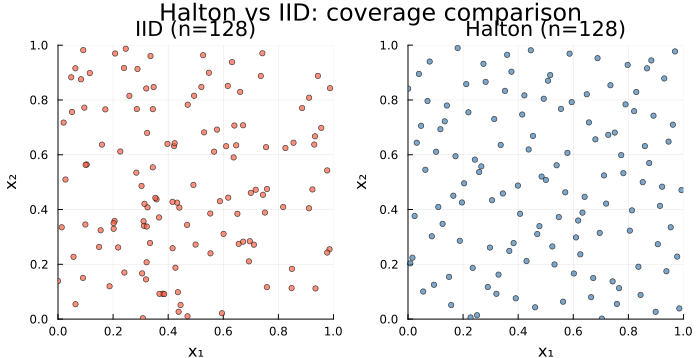

In [5]:
if HAVE_PLOTS
    # Halton vs IID scatter comparison
    n_cmp = 128
    iid_cmp = gen_samples(IIDStdUniform(2; seed=7), n_cmp)
    hal_cmp = gen_samples(Halton(2; seed=7), n_cmp)

    p1 = scatter(iid_cmp[:, 1], iid_cmp[:, 2];
        markersize=3, alpha=0.7, color=:tomato, label=nothing,
        xlabel="x₁", ylabel="x₂", title="IID (n=$n_cmp)",
        xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
    p2 = scatter(hal_cmp[:, 1], hal_cmp[:, 2];
        markersize=3, alpha=0.7, color=:steelblue, label=nothing,
        xlabel="x₁", ylabel="x₂", title="Halton (n=$n_cmp)",
        xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
    display(plot(p1, p2; layout=(1, 2), size=(700, 360),
        plot_title="Halton vs IID: coverage comparison"))
end


## Higher Dimensions

Halton sequences in higher dimensions, showing all pairwise projections.

In [6]:
# 4D Halton — show pairwise projection statistics
dimension = 4
h = Halton(dimension; seed=7)
n = 128
x = gen_samples(h, n)

println("Halton sequence: $n points in $(dimension)D")
println()
println("Pairwise correlation matrix:")
C = cor(x)
for i in 1:dimension
    println("  ", [round(C[i,j], digits=4) for j in 1:dimension])
end
println()
println("(Low correlations indicate good uniformity across projections)")

Halton sequence: 128 points in 4D

Pairwise correlation matrix:
  

[1.0, -0.0096, -0.017, 0.0073]
  [-0.0096, 1.0, -0.0168, 0.0125]
  [-0.017, -0.0168, 1.0, 0.0596]
  [0.0073, 0.0125, 0.0596, 1.0]

(Low correlations indicate good uniformity across projections)


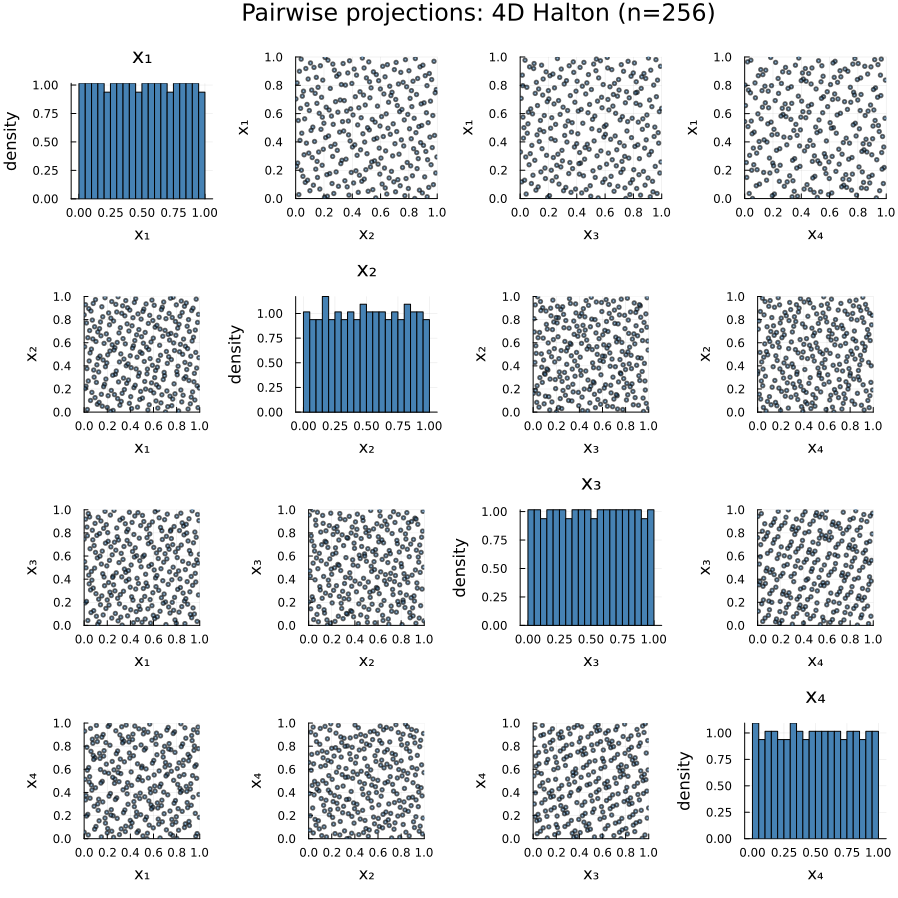

In [7]:
if HAVE_PLOTS
    # All pairwise 2D projections of 4D Halton
    h4 = Halton(4; seed=7)
    x4 = gen_samples(h4, 256)
    dim_names = ["x₁", "x₂", "x₃", "x₄"]
    pair_plts = []
    for i in 1:4, j in 1:4
        if i == j
            # Histogram on diagonal
            local p = histogram(x4[:, i]; bins=20, normalize=:pdf,
                color=:steelblue, label=nothing,
                xlabel=dim_names[i], ylabel="density",
                title=dim_names[i])
        else
            local p = scatter(x4[:, j], x4[:, i];
                markersize=2, alpha=0.6, color=:steelblue, label=nothing,
                xlabel=dim_names[j], ylabel=dim_names[i],
                xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal)
        end
        push!(pair_plts, p)
    end
    display(plot(pair_plts...; layout=(4, 4), size=(900, 900),
        plot_title="Pairwise projections: 4D Halton (n=256)"))
end


## Integration with Halton Sequences

Compare integration accuracy of Halton vs IID for the Keister function.

In [8]:
d = 3
exact = keister_exact(d)
println("Keister integral (d=$d): $(round(exact, digits=6))")
println()

let
    for n in [256, 1024, 4096]
        h_n = Halton(d; seed=7)
        tm_h = Gaussian(h_n; mean=0.0, covariance=0.5)
        f_h = Keister(tm_h)
        x_h = gen_samples(h_n, n)
        y_h = evaluate(f_h, x_h)
        est_h = mean(y_h)

        iid_n = IIDStdUniform(d; seed=7)
        tm_i = Gaussian(iid_n; mean=0.0, covariance=0.5)
        f_i = Keister(tm_i)
        x_i = gen_samples(iid_n, n)
        y_i = evaluate(f_i, x_i)
        est_i = mean(y_i)

        println("n=$n:  Halton err=$(round(abs(est_h - exact), sigdigits=3)),  " *
                "IID err=$(round(abs(est_i - exact), sigdigits=3))")
    end
end

Keister integral (d=3): 2.168309

n=256:  Halton err=0.899,  IID err=0.938


n=1024:  Halton err=0.896,  IID err=0.917
n=4096:  Halton err=0.896,  IID err=0.898


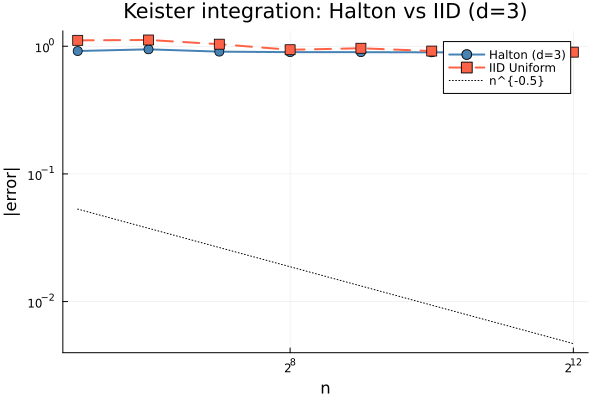

In [9]:
if HAVE_PLOTS
    # Keister integration convergence: Halton vs IID
    d_conv = 3
    exact_conv = keister_exact(d_conv)
    ns_conv = [2^k for k in 5:12]
    errs_hal = Float64[]
    errs_iid = Float64[]
    for n_c in ns_conv
        h_c = Halton(d_conv; seed=7)
        tm_h = Gaussian(h_c; mean=0.0, covariance=0.5)
        f_h  = Keister(tm_h)
        push!(errs_hal, abs(mean(evaluate(f_h, gen_samples(h_c, n_c))) - exact_conv))

        iid_c = IIDStdUniform(d_conv; seed=7)
        tm_i = Gaussian(iid_c; mean=0.0, covariance=0.5)
        f_i  = Keister(tm_i)
        push!(errs_iid, abs(mean(evaluate(f_i, gen_samples(iid_c, n_c))) - exact_conv))
    end
    p = plot(ns_conv, errs_hal;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=5, color=:steelblue,
        label="Halton (d=$d_conv)",
        xlabel="n", ylabel="|error|",
        title="Keister integration: Halton vs IID (d=$d_conv)")
    plot!(ns_conv, errs_iid;
        marker=:square, lw=2, ms=5, color=:tomato, linestyle=:dash,
        label="IID Uniform")
    ref = Float64.(ns_conv)
    plot!(ref, 0.3 .* ref .^ (-0.5); lw=1, color=:black, linestyle=:dot, label="n^{-0.5}")
    display(p)
end


## Timing Comparison

Compare sample generation speed across sequence types.

In [10]:
using Printf

n = 2^16
for (name, dd) in [
    ("IID",        IIDStdUniform(4; seed=7)),
    ("Halton",     Halton(4; seed=7)),
    ("DigitalNet", DigitalNetB2(4; seed=7)),
    ("Lattice",    Lattice(4; seed=7)),
]
    t = @elapsed gen_samples(dd, n)
    @printf("%-12s: %.4f sec for %d points\n", name, t, n)
end

IID         : 0.0002 sec for 65536 points
Halton      : 0.0124 sec for 65536 points


DigitalNet  : 0.3550 sec for 65536 points
Lattice     : 0.0977 sec for 65536 points
